In [ ]:
from google.colab import files

uploaded = files.upload()

Saving properties.csv to properties.csv
Saving clients.csv to clients (2).csv


In [ ]:
import pandas as pd

clients = pd.read_csv("clients.csv")
properties = pd.read_csv("properties.csv")

print("Clients:", clients.shape)
print("Properties:", properties.shape)

Clients: (2000, 12)
Properties: (10000, 9)


In [ ]:
print("CLIENTS DATA")
print(clients.head())

print("\nPROPERTIES DATA")
print(properties.head())

CLIENTS DATA
  client_id client_type first_name last_name date_of_birth gender country  \
0     C0001  Individual     Kareem       Liu    05-11-1968      F     USA   
1     C0002  Individual    Trystan   Oconnor    11/26/1962      M     USA   
2     C0003  Individual       Kale       Gay    04-07-1959      M     USA   
3     C0004  Individual    Russell     Gross    11/25/1959      M     USA   
4     C0005     Company    Marleez        Co     2/28/1976      M     USA   

       region acquisition_purpose  satisfaction_score loan_applied  \
0  California                Home                   4          Yes   
1  California                Home                   1           No   
2  California                Home                   4          Yes   
3  California                Home                   5           No   
4  California          Investment                   5           No   

  referral_channel  
0          Website  
1          Website  
2           Agency  
3          Website 

In [ ]:
print("CLIENTS INFORMATION")
clients.info()

print("\nPROPERTIES INFORMATION")
properties.info()

CLIENTS INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   client_id            2000 non-null   object
 1   client_type          2000 non-null   object
 2   first_name           2000 non-null   object
 3   last_name            2000 non-null   object
 4   date_of_birth        2000 non-null   object
 5   gender               2000 non-null   object
 6   country              2000 non-null   object
 7   region               2000 non-null   object
 8   acquisition_purpose  2000 non-null   object
 9   satisfaction_score   2000 non-null   int64 
 10  loan_applied         2000 non-null   object
 11  referral_channel     2000 non-null   object
dtypes: int64(1), object(11)
memory usage: 187.6+ KB

PROPERTIES INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 # 

In [ ]:
print("CLIENTS INFORMATION")
clients.info()

print("\nPROPERTIES INFORMATION")
properties.info()

CLIENTS INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   client_id            2000 non-null   object
 1   client_type          2000 non-null   object
 2   first_name           2000 non-null   object
 3   last_name            2000 non-null   object
 4   date_of_birth        2000 non-null   object
 5   gender               2000 non-null   object
 6   country              2000 non-null   object
 7   region               2000 non-null   object
 8   acquisition_purpose  2000 non-null   object
 9   satisfaction_score   2000 non-null   int64 
 10  loan_applied         2000 non-null   object
 11  referral_channel     2000 non-null   object
dtypes: int64(1), object(11)
memory usage: 187.6+ KB

PROPERTIES INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 # 

In [ ]:
print("Duplicate client rows:", clients.duplicated().sum())
print("Duplicate property rows:", properties.duplicated().sum())

Duplicate client rows: 0
Duplicate property rows: 0


In [ ]:
print("Missing values in CLIENTS:")
print(clients.isnull().sum())

print("\nMissing values in PROPERTIES:")
print(properties.isnull().sum())

Missing values in CLIENTS:
client_id              0
client_type            0
first_name             0
last_name              0
date_of_birth          0
gender                 0
country                0
region                 0
acquisition_purpose    0
satisfaction_score     0
loan_applied           0
referral_channel       0
dtype: int64

Missing values in PROPERTIES:
listing_id             0
tower_number           0
transaction_date       0
unit_category          0
unit_number            0
floor_area_sqft        0
sale_price             0
listing_status         0
client_ref          2695
dtype: int64


In [ ]:
print("Duplicate client rows:", clients.duplicated().sum())
print("Duplicate property rows:", properties.duplicated().sum())

Duplicate client rows: 0
Duplicate property rows: 0


In [ ]:
clients["date_of_birth"] = pd.to_datetime(
    clients["date_of_birth"],
    format="mixed"
)

properties["transaction_date"] = pd.to_datetime(
    properties["transaction_date"]
)

print("Client date type:", clients["date_of_birth"].dtype)
print("Transaction date type:", properties["transaction_date"].dtype)

Client date type: datetime64[ns]
Transaction date type: datetime64[ns]


In [ ]:
reference_date = pd.Timestamp("2025-12-31")

clients["age"] = (
    (reference_date - clients["date_of_birth"]).dt.days / 365.25
).round(1)

print(clients[["date_of_birth", "age"]].head())

  date_of_birth   age
0    1968-05-11  57.6
1    1962-11-26  63.1
2    1959-04-07  66.7
3    1959-11-25  66.1
4    1976-02-28  49.8


In [ ]:
properties["sale_price"] = (
    properties["sale_price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

print(properties["sale_price"].head())
print("\nData type:", properties["sale_price"].dtype)

0    300385.62
1    208930.81
2    218585.92
3    246172.68
4    212265.67
Name: sale_price, dtype: float64

Data type: float64


In [ ]:
print("CLIENTS STATISTICS")
print(clients.describe(include="all"))

CLIENTS STATISTICS
       client_id client_type first_name last_name               date_of_birth  \
count       2000        2000       2000      2000                        2000   
unique      2000           2        337       224                         NaN   
top        C1984  Individual       Carl        Co                         NaN   
freq           1        1897         24       103                         NaN   
mean         NaN         NaN        NaN       NaN  1970-05-26 02:22:33.600000   
min          NaN         NaN        NaN       NaN         1931-02-13 00:00:00   
25%          NaN         NaN        NaN       NaN         1955-12-21 12:00:00   
50%          NaN         NaN        NaN       NaN         1969-10-25 00:00:00   
75%          NaN         NaN        NaN       NaN         1985-02-19 18:00:00   
max          NaN         NaN        NaN       NaN         2000-12-19 00:00:00   
std          NaN         NaN        NaN       NaN                         NaN   

       g

In [ ]:
print("PROPERTIES STATISTICS")
print(properties.describe(include="all"))

PROPERTIES STATISTICS
           listing_id  tower_number            transaction_date unit_category  \
count    10000.000000  10000.000000                       10000         10000   
unique            NaN           NaN                         NaN             2   
top               NaN           NaN                         NaN     Apartment   
freq              NaN           NaN                         NaN          8547   
mean    105898.277400     10.370100  2024-11-07 13:03:47.520000           NaN   
min       1002.000000      1.000000         2024-01-01 00:00:00           NaN   
25%      50389.750000      5.000000         2024-05-01 00:00:00           NaN   
50%     100404.500000     10.000000         2024-10-01 00:00:00           NaN   
75%     150411.250000     15.000000         2025-05-01 00:00:00           NaN   
max     990026.000000     20.000000         2025-12-01 00:00:00           NaN   
std      74414.566199      5.769025                         NaN           NaN   

     

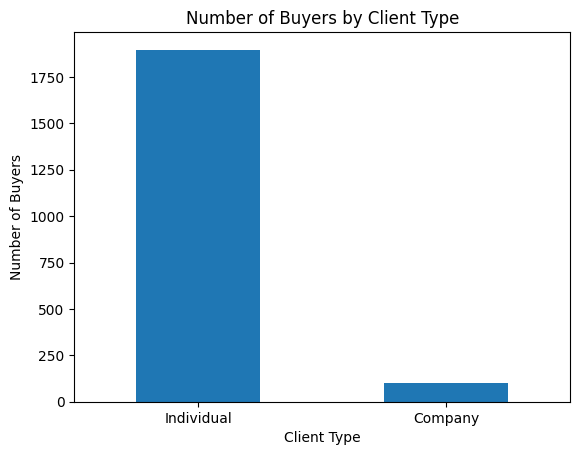

In [ ]:
import matplotlib.pyplot as plt

clients["client_type"].value_counts().plot(kind="bar")

plt.title("Number of Buyers by Client Type")
plt.xlabel("Client Type")
plt.ylabel("Number of Buyers")
plt.xticks(rotation=0)
plt.show()

In [ ]:
print(clients["client_type"].value_counts())

client_type
Individual    1897
Company        103
Name: count, dtype: int64


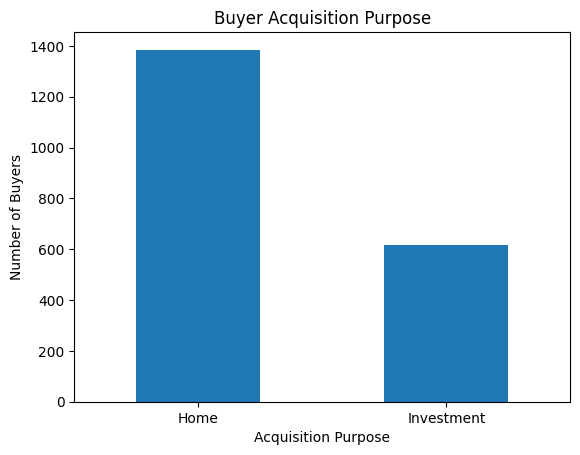

In [ ]:
clients["acquisition_purpose"].value_counts().plot(kind="bar")

plt.title("Buyer Acquisition Purpose")
plt.xlabel("Acquisition Purpose")
plt.ylabel("Number of Buyers")
plt.xticks(rotation=0)
plt.show()

In [ ]:
print(clients["acquisition_purpose"].value_counts())

acquisition_purpose
Home          1385
Investment     615
Name: count, dtype: int64


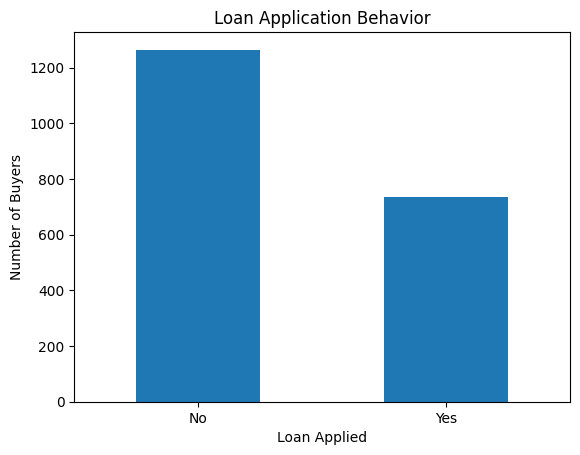

In [ ]:
clients["loan_applied"].value_counts().plot(kind="bar")

plt.title("Loan Application Behavior")
plt.xlabel("Loan Applied")
plt.ylabel("Number of Buyers")
plt.xticks(rotation=0)
plt.show()

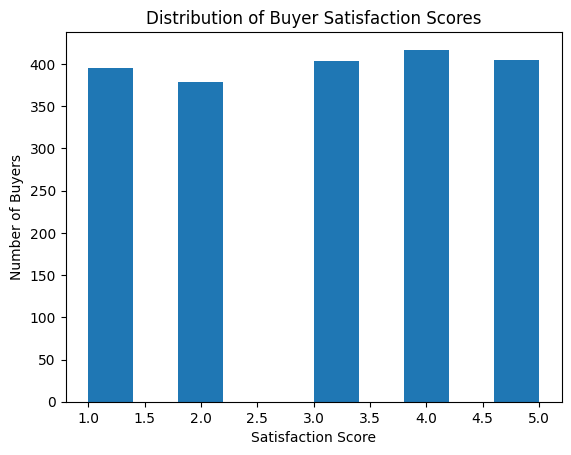

In [ ]:
plt.hist(clients["satisfaction_score"], bins=10)

plt.title("Distribution of Buyer Satisfaction Scores")
plt.xlabel("Satisfaction Score")
plt.ylabel("Number of Buyers")
plt.show()

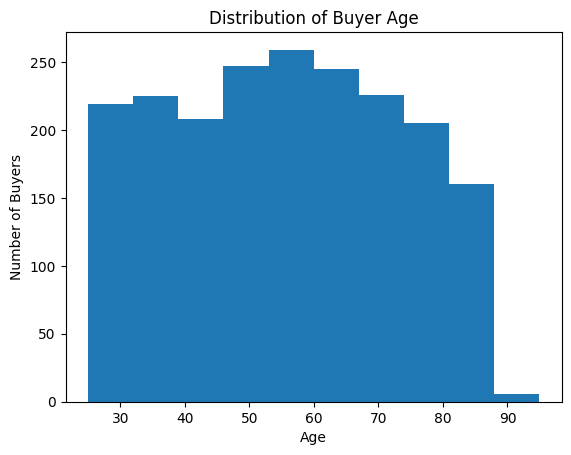

In [ ]:
plt.hist(clients["age"], bins=10)

plt.title("Distribution of Buyer Age")
plt.xlabel("Age")
plt.ylabel("Number of Buyers")
plt.show()

In [ ]:
print("Average age:", clients["age"].mean())
print("Minimum age:", clients["age"].min())
print("Maximum age:", clients["age"].max())

Average age: 55.5989
Minimum age: 25.0
Maximum age: 94.9


In [ ]:
# STEP 11: Connect clients and properties

# Keep only sold properties
sold_properties = properties[
    properties["listing_status"] == "Sold"
].copy()

# Create buyer-level property summary
property_summary = sold_properties.groupby("client_ref").agg(
    properties_bought=("listing_id", "count"),
    total_spend=("sale_price", "sum"),
    average_property_price=("sale_price", "mean"),
    total_area=("floor_area_sqft", "sum")
).reset_index()

# Connect the property summary with the client information
buyer_data = clients.merge(
    property_summary,
    left_on="client_id",
    right_on="client_ref",
    how="left"
)

# Buyers with no recorded purchases get 0
buyer_data["properties_bought"] = buyer_data["properties_bought"].fillna(0)
buyer_data["total_spend"] = buyer_data["total_spend"].fillna(0)
buyer_data["average_property_price"] = buyer_data["average_property_price"].fillna(0)
buyer_data["total_area"] = buyer_data["total_area"].fillna(0)

# Check the result
print("Buyer data shape:", buyer_data.shape)
print("\nBuyer data columns:")
print(buyer_data.columns.tolist())

print("\nFirst 5 rows:")
print(buyer_data.head())

Buyer data shape: (2000, 18)

Buyer data columns:
['client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth', 'gender', 'country', 'region', 'acquisition_purpose', 'satisfaction_score', 'loan_applied', 'referral_channel', 'age', 'client_ref', 'properties_bought', 'total_spend', 'average_property_price', 'total_area']

First 5 rows:
  client_id client_type first_name last_name date_of_birth gender country  \
0     C0001  Individual     Kareem       Liu    1968-05-11      F     USA   
1     C0002  Individual    Trystan   Oconnor    1962-11-26      M     USA   
2     C0003  Individual       Kale       Gay    1959-04-07      M     USA   
3     C0004  Individual    Russell     Gross    1959-11-25      M     USA   
4     C0005     Company    Marleez        Co    1976-02-28      M     USA   

       region acquisition_purpose  satisfaction_score loan_applied  \
0  California                Home                   4          Yes   
1  California                Home                 

In [ ]:
print("Buyer data shape:", buyer_data.shape)

print("\nTransaction features:")
print(
    buyer_data[
        [
            "client_id",
            "properties_bought",
            "total_spend",
            "average_property_price",
            "total_area"
        ]
    ].head(10)
)

Buyer data shape: (2000, 18)

Transaction features:
  client_id  properties_bought  total_spend  average_property_price  \
0     C0001                  4   1246764.72           311691.180000   
1     C0002                  5   1841095.93           368219.186000   
2     C0003                  5   1661457.59           332291.518000   
3     C0004                  6   1608263.51           268043.918333   
4     C0005                 13   3653385.38           281029.644615   
5     C0006                  5   1514131.06           302826.212000   
6     C0007                 11   3251147.83           295558.893636   
7     C0008                  5   1476730.41           295346.082000   
8     C0009                  5   1820832.35           364166.470000   
9     C0010                  5   1732434.00           346486.800000   

   total_area  
0     3935.54  
1     5939.71  
2     5290.55  
3     5622.62  
4    12054.85  
5     4947.95  
6    10952.63  
7     5155.53  
8     6528.22  
9     

In [ ]:


categorical_features = [
    "client_type",
    "gender",
    "country",
    "region",
    "acquisition_purpose",
    "loan_applied",
    "referral_channel"
]

numeric_features = [
    "age",
    "satisfaction_score",
    "properties_bought",
    "total_spend",
    "average_property_price",
    "total_area"
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numeric_features)

Categorical features:
['client_type', 'gender', 'country', 'region', 'acquisition_purpose', 'loan_applied', 'referral_channel']

Numerical features:
['age', 'satisfaction_score', 'properties_bought', 'total_spend', 'average_property_price', 'total_area']


In [ ]:
categorical_features = [
    "client_type",
    "gender",
    "country",
    "region",
    "acquisition_purpose",
    "loan_applied",
    "referral_channel"
]

numeric_features = [
    "age",
    "satisfaction_score",
    "properties_bought",
    "total_spend",
    "average_property_price",
    "total_area"
]

print("Features selected successfully!")

Features selected successfully!


In [ ]:
sold_properties = properties[
    properties["listing_status"] == "Sold"
].copy()

property_summary = sold_properties.groupby("client_ref").agg(
    properties_bought=("listing_id", "count"),
    total_spend=("sale_price", "sum"),
    average_property_price=("sale_price", "mean"),
    total_area=("floor_area_sqft", "sum")
).reset_index()

buyer_data = clients.merge(
    property_summary,
    left_on="client_id",
    right_on="client_ref",
    how="left"
)

buyer_data["properties_bought"] = buyer_data["properties_bought"].fillna(0)
buyer_data["total_spend"] = buyer_data["total_spend"].fillna(0)
buyer_data["average_property_price"] = buyer_data["average_property_price"].fillna(0)
buyer_data["total_area"] = buyer_data["total_area"].fillna(0)

print("buyer_data created successfully!")
print("Buyer data shape:", buyer_data.shape)

NameError: name 'properties' is not defined

In [ ]:
import pandas as pd

clients = pd.read_csv("clients.csv")
properties = pd.read_csv("properties.csv")

print("Clients shape:", clients.shape)
print("Properties shape:", properties.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'clients.csv'

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving properties.csv to properties.csv
Saving clients.csv to clients.csv


In [ ]:
import pandas as pd

clients = pd.read_csv("clients.csv")
properties = pd.read_csv("properties.csv")

print("Clients shape:", clients.shape)
print("Properties shape:", properties.shape)

Clients shape: (2000, 12)
Properties shape: (10000, 9)


In [ ]:
clients["date_of_birth"] = pd.to_datetime(
    clients["date_of_birth"],
    format="mixed"
)

properties["transaction_date"] = pd.to_datetime(
    properties["transaction_date"]
)

reference_date = pd.Timestamp("2025-12-31")

clients["age"] = (
    (reference_date - clients["date_of_birth"]).dt.days / 365.25
).round(1)

print("Date conversion completed!")
print(clients["age"].describe())

Date conversion completed!
count    2000.000000
mean       55.598900
std        17.349598
min        25.000000
25%        40.875000
50%        56.200000
75%        70.000000
max        94.900000
Name: age, dtype: float64


In [ ]:
properties["sale_price"] = (
    properties["sale_price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

print("Sale price cleaned successfully!")
print(properties["sale_price"].describe())

Sale price cleaned successfully!
count     10000.000000
mean     344374.678683
std      131563.099417
min       97402.800000
25%      232173.642500
50%      330680.845000
75%      448852.575000
max      736652.270000
Name: sale_price, dtype: float64


In [ ]:
sold_properties = properties[
    properties["listing_status"] == "Sold"
].copy()

print("Sold properties:", sold_properties.shape)

Sold properties: (7305, 9)


In [ ]:
property_summary = sold_properties.groupby("client_ref").agg(
    properties_bought=("listing_id", "count"),
    total_spend=("sale_price", "sum"),
    average_property_price=("sale_price", "mean"),
    total_area=("floor_area_sqft", "sum")
).reset_index()

print("Buyer transaction summary created!")
print(property_summary.head())

Buyer transaction summary created!
  client_ref  properties_bought  total_spend  average_property_price  \
0      C0001                  4   1246764.72           311691.180000   
1      C0002                  5   1841095.93           368219.186000   
2      C0003                  5   1661457.59           332291.518000   
3      C0004                  6   1608263.51           268043.918333   
4      C0005                 13   3653385.38           281029.644615   

   total_area  
0     3935.54  
1     5939.71  
2     5290.55  
3     5622.62  
4    12054.85  


In [ ]:
buyer_data = clients.merge(
    property_summary,
    left_on="client_id",
    right_on="client_ref",
    how="left"
)

print("Buyer data created successfully!")
print("Buyer data shape:", buyer_data.shape)

Buyer data created successfully!
Buyer data shape: (2000, 18)


In [ ]:
buyer_data["properties_bought"] = buyer_data["properties_bought"].fillna(0)
buyer_data["total_spend"] = buyer_data["total_spend"].fillna(0)
buyer_data["average_property_price"] = buyer_data["average_property_price"].fillna(0)
buyer_data["total_area"] = buyer_data["total_area"].fillna(0)

print("Missing purchase values handled successfully!")
print(buyer_data[
    ["properties_bought", "total_spend",
     "average_property_price", "total_area"]
].isnull().sum())

Missing purchase values handled successfully!
properties_bought         0
total_spend               0
average_property_price    0
total_area                0
dtype: int64


In [ ]:
categorical_features = [
    "client_type",
    "gender",
    "country",
    "region",
    "acquisition_purpose",
    "loan_applied",
    "referral_channel"
]

numeric_features = [
    "age",
    "satisfaction_score",
    "properties_bought",
    "total_spend",
    "average_property_price",
    "total_area"
]

print("Features selected successfully!")

Features selected successfully!


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X = preprocessor.fit_transform(buyer_data)

print("Preprocessing completed successfully!")
print("Machine learning data shape:", X.shape)

Preprocessing completed successfully!
Machine learning data shape: (2000, 84)


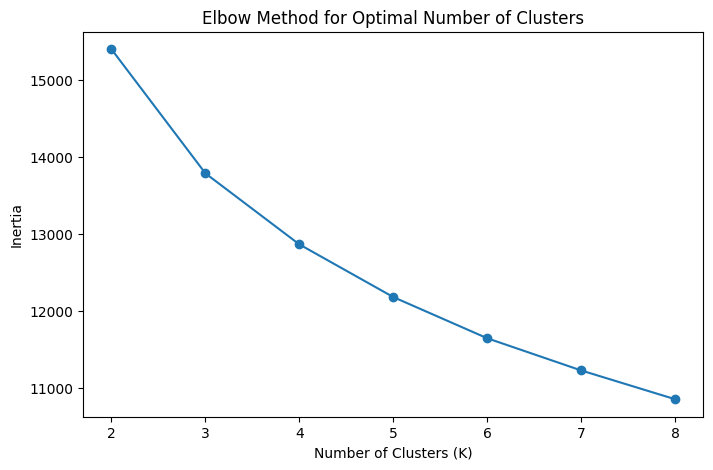

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 9), inertias, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xticks(range(2, 9))
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

for k, score in zip(range(2, 9), silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.4f}")

K = 2: Silhouette Score = 0.1562
K = 3: Silhouette Score = 0.1510
K = 4: Silhouette Score = 0.1150
K = 5: Silhouette Score = 0.1024
K = 6: Silhouette Score = 0.1003
K = 7: Silhouette Score = 0.0975
K = 8: Silhouette Score = 0.0965


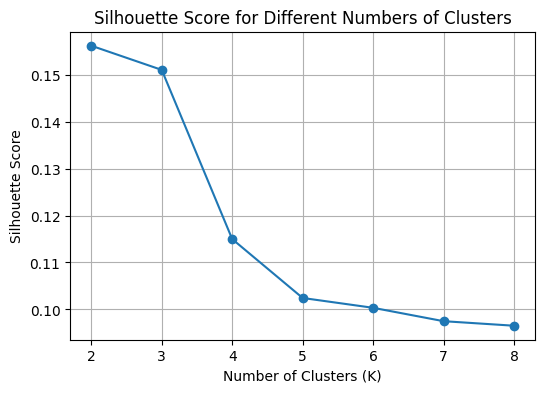

In [ ]:
import matplotlib.pyplot as plt

k_values = range(2, 9)

plt.figure(figsize=(6, 4))
plt.plot(k_values, silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different Numbers of Clusters")
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

for k, score in zip(range(2, 9), silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.4f}")

K = 2: Silhouette Score = 0.1562
K = 3: Silhouette Score = 0.1510
K = 4: Silhouette Score = 0.1150
K = 5: Silhouette Score = 0.1024
K = 6: Silhouette Score = 0.1003
K = 7: Silhouette Score = 0.0975
K = 8: Silhouette Score = 0.0965


In [ ]:
best_k = 2

print("Selected number of clusters:", best_k)

Selected number of clusters: 2


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

buyer_data["cluster"] = kmeans.fit_predict(X)

print("K-Means clustering completed successfully!")
print(buyer_data["cluster"].value_counts().sort_index())

K-Means clustering completed successfully!
cluster
0    1155
1     845
Name: count, dtype: int64


In [ ]:
cluster_summary = buyer_data.groupby("cluster").agg(
    buyers=("client_id", "count"),
    average_age=("age", "mean"),
    average_satisfaction=("satisfaction_score", "mean"),
    average_properties_bought=("properties_bought", "mean"),
    average_total_spend=("total_spend", "mean"),
    average_property_price=("average_property_price", "mean"),
    average_total_area=("total_area", "mean")
).round(2)

print(cluster_summary)

         buyers  average_age  average_satisfaction  average_properties_bought  \
cluster                                                                         
0          1155        54.76                  2.99                       3.39   
1           845        56.75                  3.09                       4.00   

         average_total_spend  average_property_price  average_total_area  
cluster                                                                   
0                 1039153.71               309012.52             3463.13  
1                 1562755.53               399136.62             5131.56  


In [ ]:
cluster_names = {
    0: "Standard Property Buyers",
    1: "High-Value Property Buyers"
}

buyer_data["segment"] = buyer_data["cluster"].map(cluster_names)

print(buyer_data["segment"].value_counts())

segment
Standard Property Buyers      1155
High-Value Property Buyers     845
Name: count, dtype: int64


In [ ]:
purpose_by_segment = pd.crosstab(
    buyer_data["segment"],
    buyer_data["acquisition_purpose"]
)

print(purpose_by_segment)

acquisition_purpose         Home  Investment
segment                                     
High-Value Property Buyers   610         235
Standard Property Buyers     775         380


In [ ]:
client_type_by_segment = pd.crosstab(
    buyer_data["segment"],
    buyer_data["client_type"]
)

print(client_type_by_segment)

client_type                 Company  Individual
segment                                        
High-Value Property Buyers       38         807
Standard Property Buyers         65        1090


In [ ]:
loan_by_segment = pd.crosstab(
    buyer_data["segment"],
    buyer_data["loan_applied"]
)

print(loan_by_segment)

loan_applied                 No  Yes
segment                             
High-Value Property Buyers  539  306
Standard Property Buyers    725  430


In [ ]:
region_by_segment = pd.crosstab(
    buyer_data["segment"],
    buyer_data["region"]
)

print(region_by_segment)

region                      Alberta  Arizona  Baja California  Bavaria  \
segment                                                                  
High-Value Property Buyers        8       44                1        6   
Standard Property Buyers         19       64                6        6   

region                      Berlin  British Columbia  Brittany  Brussels  \
segment                                                                    
High-Value Property Buyers       2                 9         8         7   
Standard Property Buyers         9                11         8         5   

region                      California  Capital Region  ...  Texas  Utah  \
segment                                                 ...                
High-Value Property Buyers         287               4  ...     19    41   
Standard Property Buyers           346               1  ...     37    46   

region                      Victoria  Virginia  Wales  Wallonia  Washington  \
segment       

In [ ]:
for segment in buyer_data["segment"].unique():
    print("\n", segment)

    top_regions = (
        buyer_data[buyer_data["segment"] == segment]["region"]
        .value_counts()
        .head(10)
    )

    print(top_regions)



 Standard Property Buyers
region
California    346
Nevada         78
Colorado       68
Arizona        64
Oregon         52
Utah           46
Washington     43
Virginia       42
Texas          37
New York       27
Name: count, dtype: int64

 High-Value Property Buyers
region
California    287
Nevada         65
Colorado       50
Oregon         44
Arizona        44
Utah           41
Washington     30
Florida        25
Virginia       23
New York       22
Name: count, dtype: int64


In [ ]:
gender_by_segment = pd.crosstab(
    buyer_data["segment"],
    buyer_data["gender"]
)

print(gender_by_segment)

gender                        F    M
segment                             
High-Value Property Buyers  398  447
Standard Property Buyers    590  565


In [ ]:
referral_by_segment = pd.crosstab(
    buyer_data["segment"],
    buyer_data["referral_channel"]
)

print(referral_by_segment)

referral_channel            Agency  Client  Website
segment                                            
High-Value Property Buyers     281      79      485
Standard Property Buyers       424     113      618


In [ ]:
country_by_segment = pd.crosstab(
    buyer_data["segment"],
    buyer_data["country"]
)

for segment in buyer_data["segment"].unique():
    print("\n", segment)
    print(
        country_by_segment.loc[segment]
        .sort_values(ascending=False)
        .head(10)
    )


 Standard Property Buyers
country
USA          867
UK            58
Canada        56
Germany       35
France        34
Australia     28
Mexico        27
Belgium       23
Russia        22
Denmark        5
Name: Standard Property Buyers, dtype: int64

 High-Value Property Buyers
country
USA          671
UK            37
Canada        29
Germany       21
Belgium       20
France        19
Russia        14
Mexico        13
Australia     11
Denmark       10
Name: High-Value Property Buyers, dtype: int64


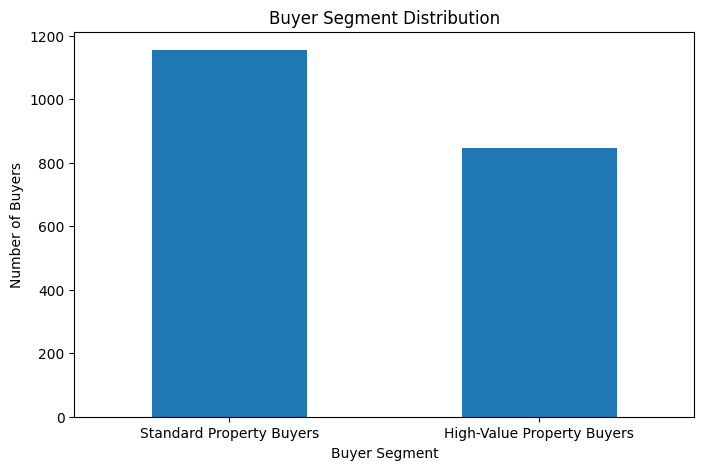

In [ ]:
import matplotlib.pyplot as plt

segment_counts = buyer_data["segment"].value_counts()

plt.figure(figsize=(8, 5))
segment_counts.plot(kind="bar")
plt.xlabel("Buyer Segment")
plt.ylabel("Number of Buyers")
plt.title("Buyer Segment Distribution")
plt.xticks(rotation=0)
plt.show()

<Figure size 800x500 with 0 Axes>

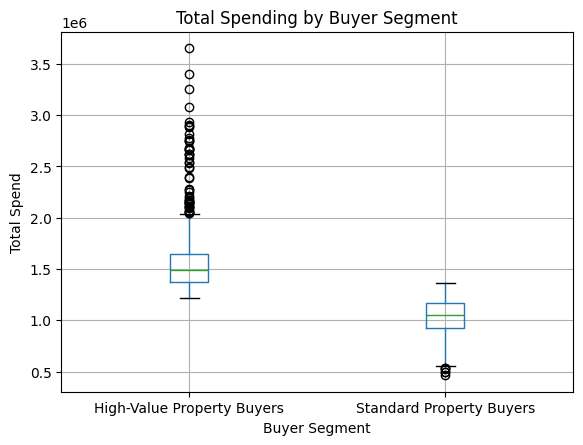

In [ ]:
plt.figure(figsize=(8, 5))

buyer_data.boxplot(
    column="total_spend",
    by="segment"
)

plt.xlabel("Buyer Segment")
plt.ylabel("Total Spend")
plt.title("Total Spending by Buyer Segment")
plt.suptitle("")
plt.xticks(rotation=0)
plt.show()

<Figure size 800x500 with 0 Axes>

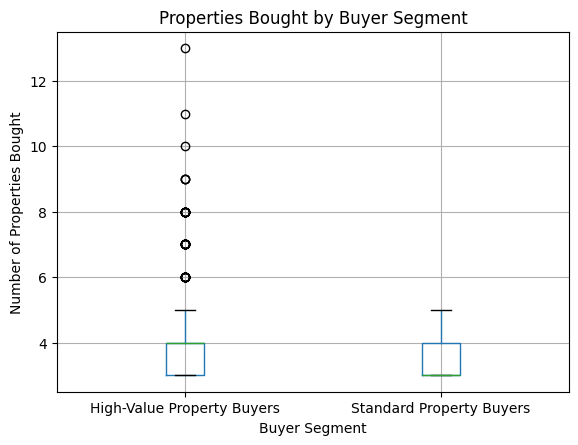

In [ ]:
plt.figure(figsize=(8, 5))

buyer_data.boxplot(
    column="properties_bought",
    by="segment"
)

plt.xlabel("Buyer Segment")
plt.ylabel("Number of Properties Bought")
plt.title("Properties Bought by Buyer Segment")
plt.suptitle("")
plt.xticks(rotation=0)
plt.show()

<Figure size 800x500 with 0 Axes>

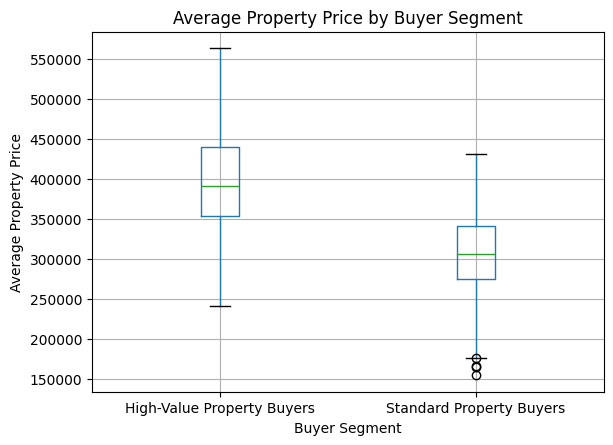

In [ ]:
plt.figure(figsize=(8, 5))

buyer_data.boxplot(
    column="average_property_price",
    by="segment"
)

plt.xlabel("Buyer Segment")
plt.ylabel("Average Property Price")
plt.title("Average Property Price by Buyer Segment")
plt.suptitle("")
plt.xticks(rotation=0)
plt.show()

<Figure size 800x500 with 0 Axes>

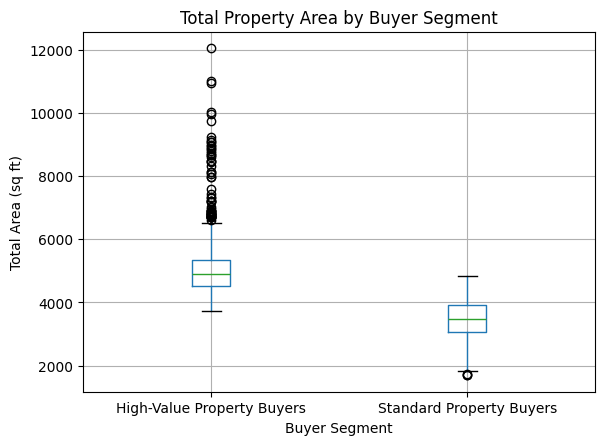

In [ ]:
plt.figure(figsize=(8, 5))

buyer_data.boxplot(
    column="total_area",
    by="segment"
)

plt.xlabel("Buyer Segment")
plt.ylabel("Total Area (sq ft)")
plt.title("Total Property Area by Buyer Segment")
plt.suptitle("")
plt.xticks(rotation=0)
plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

hierarchical = AgglomerativeClustering(
    n_clusters=best_k
)

hierarchical_labels = hierarchical.fit_predict(X.toarray())

hierarchical_silhouette = silhouette_score(
    X,
    hierarchical_labels
)

print("Hierarchical Clustering Silhouette Score:",
      round(hierarchical_silhouette, 4))

Hierarchical Clustering Silhouette Score: 0.0932


In [ ]:
final_summary = buyer_data.groupby("segment").agg(
    buyers=("client_id", "count"),
    average_age=("age", "mean"),
    average_satisfaction=("satisfaction_score", "mean"),
    average_properties_bought=("properties_bought", "mean"),
    average_total_spend=("total_spend", "mean"),
    average_property_price=("average_property_price", "mean"),
    average_total_area=("total_area", "mean")
).round(2)

print(final_summary)

                            buyers  average_age  average_satisfaction  \
segment                                                                 
High-Value Property Buyers     845        56.75                  3.09   
Standard Property Buyers      1155        54.76                  2.99   

                            average_properties_bought  average_total_spend  \
segment                                                                      
High-Value Property Buyers                       4.00           1562755.53   
Standard Property Buyers                         3.39           1039153.71   

                            average_property_price  average_total_area  
segment                                                                 
High-Value Property Buyers               399136.62             5131.56  
Standard Property Buyers                 309012.52             3463.13  


In [ ]:
buyer_data.to_csv(
    "processed_buyer_data.csv",
    index=False
)

print("Processed dataset saved successfully.")
print("Shape:", buyer_data.shape)

Processed dataset saved successfully.
Shape: (2000, 20)


In [ ]:
print(buyer_data.columns.tolist())

['client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth', 'gender', 'country', 'region', 'acquisition_purpose', 'satisfaction_score', 'loan_applied', 'referral_channel', 'age', 'client_ref', 'properties_bought', 'total_spend', 'average_property_price', 'total_area', 'cluster', 'segment']


In [ ]:
from google.colab import files

files.download("processed_buyer_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install streamlit pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 86.3 MB/s eta 0:00:00


In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd

st.set_page_config(
    page_title="Real Estate Buyer Segmentation",
    page_icon="🏠",
    layout="wide"
)

st.title("🏠 Real Estate Buyer Segmentation")
st.write("Machine Learning Based Buyer Segmentation and Investment Profiling")

# Load processed dataset
df = pd.read_csv("processed_buyer_data.csv")

st.success("Dashboard data loaded successfully!")

st.subheader("Dataset Overview")

col1, col2, col3 = st.columns(3)

with col1:
    st.metric("Total Buyers", len(df))

with col2:
    st.metric("Total Segments", df["segment"].nunique())

with col3:
    st.metric("Total Properties Bought", int(df["properties_bought"].sum()))

st.subheader("Buyer Data")

st.dataframe(df.head(20))

Overwriting app.py


In [ ]:
!streamlit run app.py



2026-10-08 15:56:36.387 Uvicorn server started on :::8502

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8502
  Network URL: http://172.28.0.12:8502
  External URL: http://34.106.181.75:8502

  Stopping...


In [ ]:
from google.colab.output import eval_js
print(eval_js('google.colab.kernel.proxyPort(8502)'))

https://8502-m-s-kkb-usw3b1-2hj7khpvvbea5-b.us-west3-1.prod.colab.dev


In [ ]:
from google.colab.output import eval_js
print(eval_js('google.colab.kernel.proxyPort(8501)'))

https://8501-m-s-kkb-usw3b1-2hj7khpvvbea5-b.us-west3-1.prod.colab.dev


In [ ]:
!streamlit run app.py --server.port 8501 &



2026-10-08 09:41:59.175 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.106.181.75:8501

  Stopping...


In [ ]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print(public_url)

ERROR:pyngrok.process.ngrok:t=2026-10-08T09:46:32+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: This ngrok session is not authenticated. ngrok requires an account and a valid credential to start a session.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nGet your credential: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-10-08T09:46:32+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: This ngrok session is not authenticated. ngrok requires an account and a valid credential to start a session.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nGet your credential: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"


PyngrokNgrokError: The ngrok process errored on start: authentication failed: This ngrok session is not authenticated. ngrok requires an account and a valid credential to start a session.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nGet your credential: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.

In [ ]:
!streamlit run app.py --server.port 8501 > streamlit.log 2>&1 &


In [ ]:
print(open("streamlit.log").read())



2026-10-08 09:48:10.594 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.106.181.75:8501




In [ ]:
from google.colab.output import eval_js

url = eval_js("google.colab.kernel.proxyPort(8501)")
print(url)

https://8501-m-s-kkb-usw3b1-2hj7khpvvbea5-b.us-west3-1.prod.colab.dev


In [ ]:
!curl -I http://localhost:8501

HTTP/1.1 200 OK
date: Thu, 08 Oct 2026 09:52:35 GMT
server: uvicorn
content-type: text/html; charset=utf-8
accept-ranges: bytes
content-length: 6463
last-modified: Thu, 08 Oct 2026 09:31:52 GMT
etag: "7783c6944ddfe29f00a505d8c64fb7d8"
cache-control: no-cache



In [ ]:
import requests

response = requests.get("http://localhost:8501")

print("Status:", response.status_code)
print("Page received:", len(response.text), "characters")
print(response.text[:200])

Status: 200
Page received: 6463 characters
<!--
 Copyright (c) Streamlit Inc. (2018-2022) Snowflake Inc. (2022-2026)

 Licensed under the Apache License, Version 2.0 (the "License");
 you may not use this file except in compliance with the Lic


In [ ]:
from google.colab import output

output.serve_kernel_port_as_window(8501)

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("PASTE_YOUR_TOKEN_HERE")

print("ngrok authentication successful!")

ngrok authentication successful!


In [ ]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print("Your Streamlit Dashboard:")
print(public_url)

ERROR:pyngrok.process.ngrok:t=2026-10-08T10:04:26+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: PASTE_YOUR_TOKEN_HERE\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n"


PyngrokNgrokError: The ngrok process errored on start: authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: PASTE_YOUR_TOKEN_HERE\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n.

In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("3KPJfHy8fj04XOd2bPCgHxqAJ8r_4WUPDtxDakhTPr9GRfQxu")

print("ngrok authentication successful!")

ngrok authentication successful!


In [ ]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print("Your Streamlit Dashboard:")
print(public_url)

Your Streamlit Dashboard:
NgrokTunnel: "https://squiggle-cussed-vacate.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import plotly.express as px

st.set_page_config(
    page_title="Real Estate Buyer Segmentation",
    page_icon="🏠",
    layout="wide"
)

# Load data
df = pd.read_csv("processed_buyer_data.csv")

st.title("🏠 Real Estate Buyer Segmentation")
st.write("Machine Learning Based Buyer Segmentation and Investment Profiling")

st.success("Dashboard data loaded successfully!")

# ==============================
# Dataset Overview
# ==============================

st.header("📊 Buyer Segmentation Overview")

col1, col2, col3 = st.columns(3)

with col1:
    st.metric("Total Buyers", len(df))

with col2:
    st.metric("Total Segments", df["segment"].nunique())

with col3:
    st.metric(
        "Total Properties Bought",
        int(df["properties_bought"].sum())
    )

# ==============================
# Segment Distribution
# ==============================

st.subheader("Buyer Segment Distribution")

segment_counts = df["segment"].value_counts().reset_index()
segment_counts.columns = ["Segment", "Buyers"]

fig = px.bar(
    segment_counts,
    x="Segment",
    y="Buyers",
    title="Number of Buyers in Each Segment",
    text="Buyers"
)

fig.update_layout(
    xaxis_title="Buyer Segment",
    yaxis_title="Number of Buyers"
)

st.plotly_chart(fig, use_container_width=True)

# ==============================
# Buyer Data
# ==============================

st.subheader("Buyer Data")

st.dataframe(df.head(20), use_container_width=True)

Overwriting app.py


In [ ]:
!pkill -f "streamlit run app.py" || true

^C


In [ ]:
!streamlit run app.py --server.port 8501 > streamlit.log 2>&1 &

In [ ]:
!streamlit run app.py --server.port 8501 > streamlit.log 2>&1 &

In [ ]:
from pyngrok import ngrok

# Close any old tunnels
ngrok.kill()

# Create a new public tunnel
public_url = ngrok.connect(8501)

print("YOUR NEW STREAMLIT LINK:")
print(public_url)

YOUR NEW STREAMLIT LINK:
NgrokTunnel: "https://squiggle-cussed-vacate.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import plotly.express as px

st.set_page_config(
    page_title="Real Estate Buyer Segmentation",
    page_icon="🏠",
    layout="wide"
)

# Load data
df = pd.read_csv("processed_buyer_data.csv")

st.title("🏠 Real Estate Buyer Segmentation")
st.write("Machine Learning Based Buyer Segmentation and Investment Profiling")

st.success("Dashboard data loaded successfully!")

# ==============================
# SIDEBAR FILTERS
# ==============================

st.sidebar.header("🔎 Filters")

country_options = ["All"] + sorted(df["country"].dropna().unique().tolist())
region_options = ["All"] + sorted(df["region"].dropna().unique().tolist())
purpose_options = ["All"] + sorted(df["acquisition_purpose"].dropna().unique().tolist())
client_type_options = ["All"] + sorted(df["client_type"].dropna().unique().tolist())

selected_country = st.sidebar.selectbox(
    "Country",
    country_options
)

selected_region = st.sidebar.selectbox(
    "Region",
    region_options
)

selected_purpose = st.sidebar.selectbox(
    "Acquisition Purpose",
    purpose_options
)

selected_client_type = st.sidebar.selectbox(
    "Client Type",
    client_type_options
)

# ==============================
# APPLY FILTERS
# ==============================

filtered_df = df.copy()

if selected_country != "All":
    filtered_df = filtered_df[
        filtered_df["country"] == selected_country
    ]

if selected_region != "All":
    filtered_df = filtered_df[
        filtered_df["region"] == selected_region
    ]

if selected_purpose != "All":
    filtered_df = filtered_df[
        filtered_df["acquisition_purpose"] == selected_purpose
    ]

if selected_client_type != "All":
    filtered_df = filtered_df[
        filtered_df["client_type"] == selected_client_type
    ]

# ==============================
# DATASET OVERVIEW
# ==============================

st.header("📊 Buyer Segmentation Overview")

col1, col2, col3 = st.columns(3)

with col1:
    st.metric(
        "Total Buyers",
        len(filtered_df)
    )

with col2:
    st.metric(
        "Total Segments",
        filtered_df["segment"].nunique()
    )

with col3:
    st.metric(
        "Total Properties Bought",
        int(filtered_df["properties_bought"].sum())
    )

# ==============================
# SEGMENT DISTRIBUTION
# ==============================

st.subheader("Buyer Segment Distribution")

segment_counts = (
    filtered_df["segment"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = ["Segment", "Buyers"]

fig = px.bar(
    segment_counts,
    x="Segment",
    y="Buyers",
    title="Number of Buyers in Each Segment",
    text="Buyers"
)

fig.update_layout(
    xaxis_title="Buyer Segment",
    yaxis_title="Number of Buyers"
)

st.plotly_chart(
    fig,
    use_container_width=True
)

# ==============================
# BUYER DATA
# ==============================

st.subheader("Buyer Data")

st.dataframe(
    filtered_df.head(20),
    use_container_width=True
)

Overwriting app.py


In [ ]:
!pkill -f "streamlit run app.py" || true

^C


In [ ]:
!streamlit run app.py --server.port 8501 > streamlit.log 2>&1 &

In [ ]:
from pyngrok import ngrok

ngrok.kill()

public_url = ngrok.connect(8501)

print("YOUR UPDATED STREAMLIT LINK:")
print(public_url)

YOUR UPDATED STREAMLIT LINK:
NgrokTunnel: "https://squiggle-cussed-vacate.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
%%writefile -a app.py

# ==============================
# INVESTOR / BUYER BEHAVIOR
# ==============================

st.header("💰 Investor Behavior Dashboard")

behavior_summary = filtered_df.groupby("segment").agg(
    total_spend=("total_spend", "mean"),
    properties_bought=("properties_bought", "mean"),
    total_area=("total_area", "mean")
).reset_index()

col1, col2 = st.columns(2)

with col1:
    fig_spend = px.bar(
        behavior_summary,
        x="segment",
        y="total_spend",
        title="Average Total Spend by Segment",
        text_auto=".2s"
    )

    fig_spend.update_layout(
        xaxis_title="Buyer Segment",
        yaxis_title="Average Total Spend"
    )

    st.plotly_chart(
        fig_spend,
        use_container_width=True
    )

with col2:
    fig_properties = px.bar(
        behavior_summary,
        x="segment",
        y="properties_bought",
        title="Average Properties Bought by Segment",
        text_auto=".2f"
    )

    fig_properties.update_layout(
        xaxis_title="Buyer Segment",
        yaxis_title="Average Properties Bought"
    )

    st.plotly_chart(
        fig_properties,
        use_container_width=True
    )

fig_area = px.bar(
    behavior_summary,
    x="segment",
    y="total_area",
    title="Average Total Area Purchased by Segment",
    text_auto=".2f"
)

fig_area.update_layout(
    xaxis_title="Buyer Segment",
    yaxis_title="Average Total Area (sq ft)"
)

st.plotly_chart(
    fig_area,
    use_container_width=True
)

Appending to app.py


In [ ]:
!pkill -f "streamlit run app.py" || true

^C


In [ ]:
!streamlit run app.py --server.port 8501 > streamlit.log 2>&1 &

In [ ]:
from pyngrok import ngrok

ngrok.kill()

public_url = ngrok.connect(8501)

print("YOUR UPDATED STREAMLIT LINK:")
print(public_url)

YOUR UPDATED STREAMLIT LINK:
NgrokTunnel: "https://squiggle-cussed-vacate.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
%%writefile -a app.py

# ==============================
# GEOGRAPHIC BUYER ANALYSIS
# ==============================

st.header("🌍 Geographic Buyer Analysis")

region_counts = (
    filtered_df["region"]
    .value_counts()
    .reset_index()
)

region_counts.columns = ["Region", "Buyers"]

# Show top 10 regions
top_regions = region_counts.head(10)

fig_region = px.bar(
    top_regions,
    x="Buyers",
    y="Region",
    orientation="h",
    title="Top 10 Regions by Number of Buyers",
    text="Buyers"
)

fig_region.update_layout(
    xaxis_title="Number of Buyers",
    yaxis_title="Region"
)

st.plotly_chart(
    fig_region,
    use_container_width=True
)

Appending to app.py


In [ ]:
!pkill -f "streamlit run app.py" || true

^C


In [ ]:
!streamlit run app.py --server.port 8501 > streamlit.log 2>&1 &

In [ ]:
from pyngrok import ngrok

ngrok.kill()

public_url = ngrok.connect(8501)

print("YOUR UPDATED STREAMLIT LINK:")
print(public_url)

YOUR UPDATED STREAMLIT LINK:
NgrokTunnel: "https://squiggle-cussed-vacate.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
%%writefile -a app.py

# ==============================
# SEGMENT INSIGHTS PANEL
# ==============================

st.header("💡 Segment Insights Panel")

insights = filtered_df.groupby("segment").agg(
    Buyers=("client_id", "count"),
    Average_Age=("age", "mean"),
    Average_Satisfaction=("satisfaction_score", "mean"),
    Average_Properties_Bought=("properties_bought", "mean"),
    Average_Total_Spend=("total_spend", "mean"),
    Average_Property_Price=("average_property_price", "mean"),
    Average_Total_Area=("total_area", "mean")
).round(2)

st.dataframe(
    insights,
    use_container_width=True
)

st.subheader("📌 Segment Interpretation")

for segment in filtered_df["segment"].unique():

    segment_data = filtered_df[
        filtered_df["segment"] == segment
    ]

    avg_spend = segment_data["total_spend"].mean()
    avg_properties = segment_data["properties_bought"].mean()

    st.write(
        f"**{segment}:** "
        f"Average total spend is ${avg_spend:,.2f}, "
        f"with an average of {avg_properties:.2f} properties bought per buyer."
    )

Appending to app.py


In [ ]:
!pkill -f "streamlit run app.py" || true

^C


In [ ]:
!streamlit run app.py --server.port 8501 > streamlit.log 2>&1 &

In [ ]:
from pyngrok import ngrok

ngrok.kill()

public_url = ngrok.connect(8501)

print("YOUR UPDATED STREAMLIT LINK:")
print(public_url)

YOUR UPDATED STREAMLIT LINK:
NgrokTunnel: "https://squiggle-cussed-vacate.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
from google.colab import files

files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
inertias = []

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

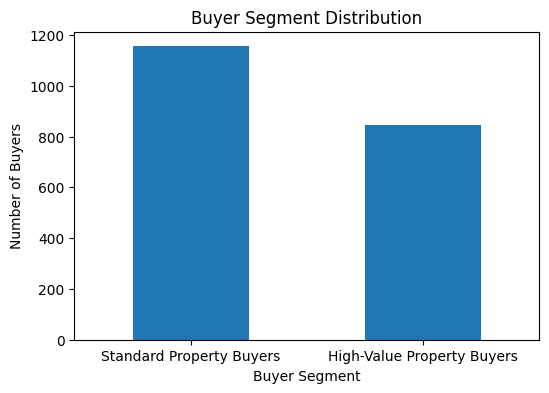

In [ ]:
import matplotlib.pyplot as plt

segment_counts = buyer_data["segment"].value_counts()

plt.figure(figsize=(6, 4))
segment_counts.plot(kind="bar")
plt.xlabel("Buyer Segment")
plt.ylabel("Number of Buyers")
plt.title("Buyer Segment Distribution")
plt.xticks(rotation=0)
plt.show()

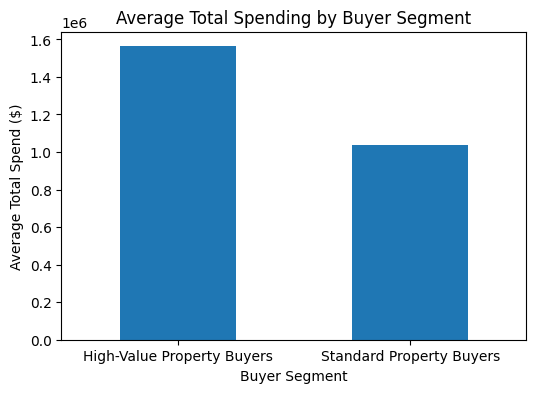

In [ ]:
import matplotlib.pyplot as plt

spend_by_segment = buyer_data.groupby("segment")["total_spend"].mean()

plt.figure(figsize=(6, 4))
spend_by_segment.plot(kind="bar")
plt.xlabel("Buyer Segment")
plt.ylabel("Average Total Spend ($)")
plt.title("Average Total Spending by Buyer Segment")
plt.xticks(rotation=0)
plt.show()

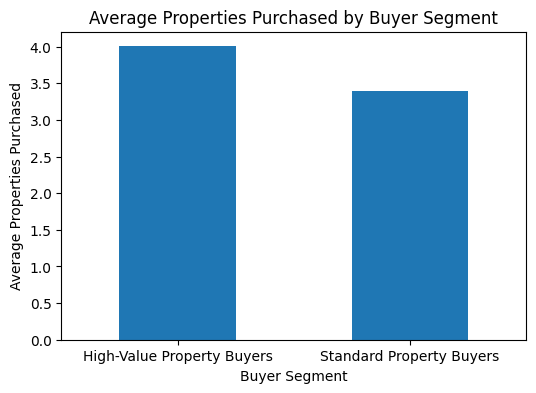

In [ ]:
import matplotlib.pyplot as plt

properties_by_segment = buyer_data.groupby("segment")["properties_bought"].mean()

plt.figure(figsize=(6, 4))
properties_by_segment.plot(kind="bar")
plt.xlabel("Buyer Segment")
plt.ylabel("Average Properties Purchased")
plt.title("Average Properties Purchased by Buyer Segment")
plt.xticks(rotation=0)
plt.show()

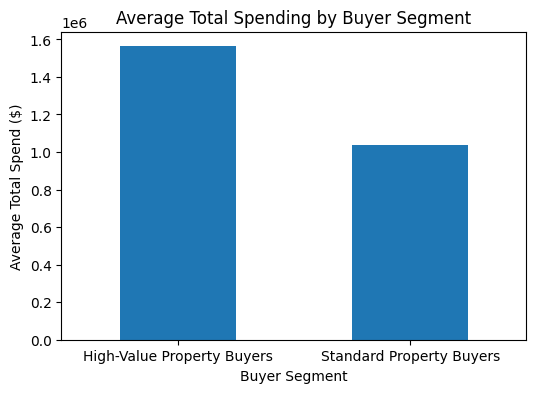

In [ ]:
import matplotlib.pyplot as plt

spend_by_segment = buyer_data.groupby("segment")["total_spend"].mean()

plt.figure(figsize=(6, 4))
spend_by_segment.plot(kind="bar")
plt.xlabel("Buyer Segment")
plt.ylabel("Average Total Spend ($)")
plt.title("Average Total Spending by Buyer Segment")
plt.xticks(rotation=0)
plt.show()

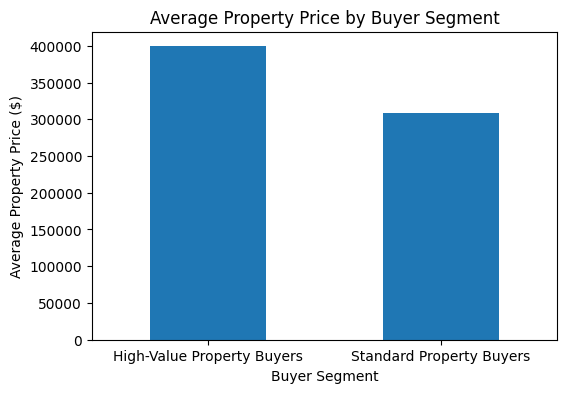

In [ ]:
import matplotlib.pyplot as plt

price_by_segment = buyer_data.groupby("segment")["average_property_price"].mean()

plt.figure(figsize=(6, 4))
price_by_segment.plot(kind="bar")
plt.xlabel("Buyer Segment")
plt.ylabel("Average Property Price ($)")
plt.title("Average Property Price by Buyer Segment")
plt.xticks(rotation=0)
plt.show()

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

clients['Cluster'] = clusters

NameError: name 'X_scaled' is not defined

In [ ]:
%whos

Variable                  Type                       Data/Info
--------------------------------------------------------------
AgglomerativeClustering   type                       <class 'sklearn.cluster._<...>AgglomerativeClustering'>
ColumnTransformer         ABCMeta                    <class 'sklearn.compose._<...>ormer.ColumnTransformer'>
KMeans                    ABCMeta                    <class 'sklearn.cluster._kmeans.KMeans'>
OneHotEncoder             type                       <class 'sklearn.preproces<...>_encoders.OneHotEncoder'>
StandardScaler            type                       <class 'sklearn.preproces<...>ng._data.StandardScaler'>
X                         csr_matrix                 <Compressed Sparse Row sp<...>80)	1.0\n  (1999, 81)	1.0
best_k                    int                        2
buyer_data                DataFrame                       client_id client_typ<...>n[2000 rows x 20 columns]
categorical_features      list                       n=7
client_type_by

In [ ]:
print("Cluster Names:")
print(cluster_names)

print("\nCluster Summary:")
display(cluster_summary)

print("\nFinal Summary:")
display(final_summary)

Cluster Names:
{0: 'Standard Property Buyers', 1: 'High-Value Property Buyers'}

Cluster Summary:


,buyers,average_age,average_satisfaction,average_properties_bought,average_total_spend,average_property_price,average_total_area
cluster,,,,,,,
0,1155,54.76,2.99,3.39,1039153.71,309012.52,3463.13
1,845,56.75,3.09,4.00,1562755.53,399136.62,5131.56



Final Summary:


,buyers,average_age,average_satisfaction,average_properties_bought,average_total_spend,average_property_price,average_total_area
segment,,,,,,,
High-Value Property Buyers,845,56.75,3.09,4.00,1562755.53,399136.62,5131.56
Standard Property Buyers,1155,54.76,2.99,3.39,1039153.71,309012.52,3463.13


In [ ]:
print("Segment Counts:")
print(segment_counts)

print("\nAverage Property Price:")
display(price_by_segment)

print("\nAverage Total Spend:")
display(spend_by_segment)

Segment Counts:
segment
Standard Property Buyers      1155
High-Value Property Buyers     845
Name: count, dtype: int64

Average Property Price:


,average_property_price
segment,
High-Value Property Buyers,399136.624410
Standard Property Buyers,309012.523041



Average Total Spend:


,total_spend
segment,
High-Value Property Buyers,1.562756e+06
Standard Property Buyers,1.039154e+06


In [ ]:
final_summary = cluster_summary.copy()

final_summary.index = final_summary.index.map(cluster_names)

display(final_summary)

,buyers,average_age,average_satisfaction,average_properties_bought,average_total_spend,average_property_price,average_total_area
cluster,,,,,,,
Standard Property Buyers,1155,54.76,2.99,3.39,1039153.71,309012.52,3463.13
High-Value Property Buyers,845,56.75,3.09,4.00,1562755.53,399136.62,5131.56


In [ ]:
print("=== Average Property Price ===")
display(price_by_segment)

print("=== Average Total Spend ===")
display(spend_by_segment)

print("=== Average Properties Bought ===")
display(properties_by_segment)

print("=== Acquisition Purpose ===")
display(purpose_by_segment)

print("=== Loan Applied ===")
display(loan_by_segment)

=== Average Property Price ===


,average_property_price
segment,
High-Value Property Buyers,399136.624410
Standard Property Buyers,309012.523041


=== Average Total Spend ===


,total_spend
segment,
High-Value Property Buyers,1.562756e+06
Standard Property Buyers,1.039154e+06


=== Average Properties Bought ===


,properties_bought
segment,
High-Value Property Buyers,4.004734
Standard Property Buyers,3.394805


=== Acquisition Purpose ===


acquisition_purpose,Home,Investment
segment,,
High-Value Property Buyers,610,235
Standard Property Buyers,775,380


=== Loan Applied ===


loan_applied,No,Yes
segment,,
High-Value Property Buyers,539,306
Standard Property Buyers,725,430


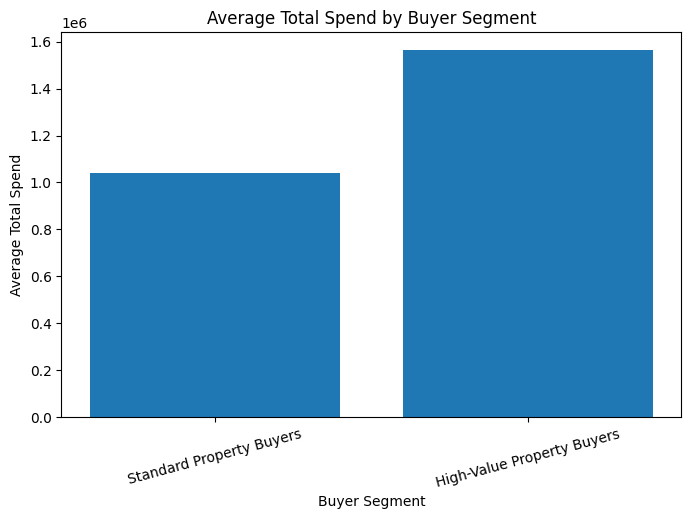

In [ ]:
import matplotlib.pyplot as plt

segments = ['Standard Property Buyers', 'High-Value Property Buyers']
spend = [1039153.71, 1562755.53]

plt.figure(figsize=(8,5))
plt.bar(segments, spend)
plt.title('Average Total Spend by Buyer Segment')
plt.xlabel('Buyer Segment')
plt.ylabel('Average Total Spend')
plt.xticks(rotation=15)
plt.show()